Part 1: Attention Map Visualization   

* lets load a pre0trained Dino-v2 to run iamges through and extract self-attention maps. 

* overlay visualizations from the cls_token row and visualize it.

* compare to a pre-trained CLIP Vit. 

* bonus: use (LiFT Model)[https://github.com/bpiyush/LiFT/] to make chirality-aware embeddings from DinoV2 in videos for more temporally coherent video embddings. 


Part 2: Frozen Feature Extraction + Linear Probing

* We can load the CIFAR-100 dataset we have been wokring on thus far, extract cls embeddings from Dinov2 to train a simple `nn.Linear` classifier on top of the frozen model's embeddings. Compare accuracy on our vanilla implrementations. 



Part 3: Survey Table

* Finally, we create a quick survey of the self-supervised vision models out there.


For each method (DINOv1, DINOv2, DINOv3, BEiT, JEPA, V-JEPAv2) we get:
  - What does it predict? (distillation targets / pixels / visual tokens / representations)
  - Architecture (pure ViT vs hybrid)
  - Does it need fine-tuning or do frozen features work?
  - Insights

### Part1

In [1]:
import torch                                                                                                                                                   
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from PIL import Image
import requests
from io import BytesIO

In [2]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dinov2.eval()
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
dinov2 = dinov2.to(device)

Using cache found in /Users/jpoberhauser/.cache/torch/hub/facebookresearch_dinov2_main
/Users/jpoberhauser/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/jpoberhauser/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/jpoberhauser/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


* the loaded model is a ViT-S/14 which means its a patch size of 14 on a 224x224 image. This should give us 256 patches to work on and the cls_token

In [14]:
from torchvision.datasets import CIFAR100
transform = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),
      transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
  ])

In [92]:
train_dataset_raw = CIFAR100(root='./data', train=True, download=True, transform=transform)
img, label = train_dataset_raw[-1]  # [3, 56, 56]

Label: 73 → shark


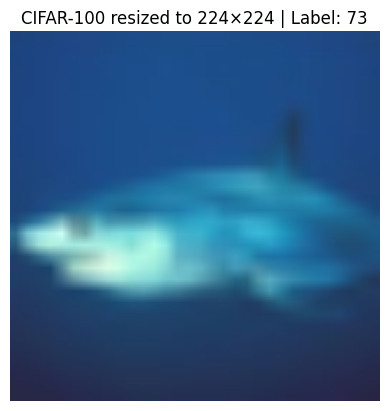

In [93]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_display = (img * std + mean).clamp(0, 1)

plt.imshow(img_display.permute(1, 2, 0))  # [3, 56, 56] -> [56, 56, 3]                                                                            
plt.title(f"CIFAR-100 resized to 224×224 | Label: {label}")                                                                                 
plt.axis('off')      
class_names = train_dataset_raw.classes  # list of 100 class names                                                                        
print(f"Label: {label} → {class_names[label]}")                                                                                                                     
plt.show()                                                                                                                                
             

In [94]:
dinov2.to(device)

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (n

In [95]:
img = img.to(device)
outs = dinov2(img.unsqueeze(0)) # this is just the cls_token embedding!

In [96]:
outs.shape

torch.Size([1, 384])

In [97]:
attention_maps = {}                                                                                                                                            
                
def hook_fn(module, input, output):
    # output is a tuple, the attention weights are computed inside
    # We need to get at the attention weights before they're multiplied by V
    attention_maps['last'] = output

In [98]:
print(dinov2.blocks[-1].attn)

MemEffAttention(
  (qkv): Linear(in_features=384, out_features=1152, bias=True)
  (attn_drop): Dropout(p=0.0, inplace=False)
  (proj): Linear(in_features=384, out_features=384, bias=True)
  (proj_drop): Dropout(p=0.0, inplace=False)
)


In [99]:
with torch.no_grad():
    out = dinov2.get_intermediate_layers(img.unsqueeze(0).to(device),
                                        n=1,
                                        return_class_token=True)

In [100]:
with torch.no_grad():
    # Prepare tokens the same way the model does
    x = dinov2.prepare_tokens_with_masks(img.unsqueeze(0).to(device))

    # Run through all blocks, grab attention from the last one
    for i, block in enumerate(dinov2.blocks):
        if i < len(dinov2.blocks) - 1:
            x = block(x)
        else:
            # Last block — manually get attention
            attn = block.attn
            B, N, C = x.shape
            qkv = attn.qkv(block.norm1(x)).reshape(B, N, 3, attn.num_heads, C // attn.num_heads).permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]
            attn_weights = (q @ k.transpose(-2, -1)) * attn.scale
            attn_weights = attn_weights.softmax(dim=-1)

In [101]:
print(attn_weights.shape)

torch.Size([1, 6, 257, 257])


In [102]:
## the cls_token is now in 
cls_attn = attn_weights[0, :, 0, 1:] # this tells us how each of the 6 heads is attentfing to the patches in the image
cls_attn.shape

torch.Size([6, 256])

In [103]:
cls_attn = cls_attn.reshape(6, 16, 16) 

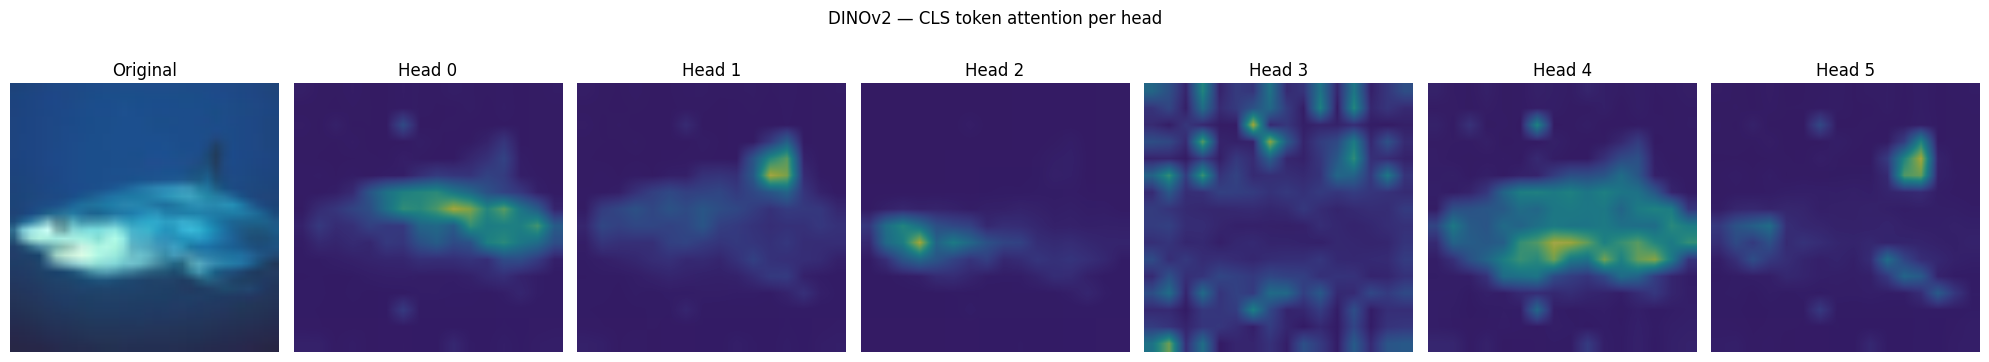

In [104]:
fig, axes = plt.subplots(1, 7, figsize=(20, 4))

# Original image
axes[0].imshow(img_display.permute(1, 2, 0))
axes[0].set_title("Original")

# Each head's attention
for i in range(6):
    axes[i+1].imshow(img_display.permute(1, 2, 0))
    axes[i+1].imshow(cls_attn[i].cpu(), alpha=0.6, cmap='viridis', interpolation='bilinear')
    axes[i+1].set_title(f"Head {i}")

for ax in axes:
    ax.axis('off')
plt.suptitle("DINOv2 — CLS token attention per head")
plt.tight_layout()
plt.show()

* so now, we can actually visualize the attention maps of each of the heads in Dinov2. 

* below, we can pick a specific patch and see which other patches it pays high attention to, in each head.

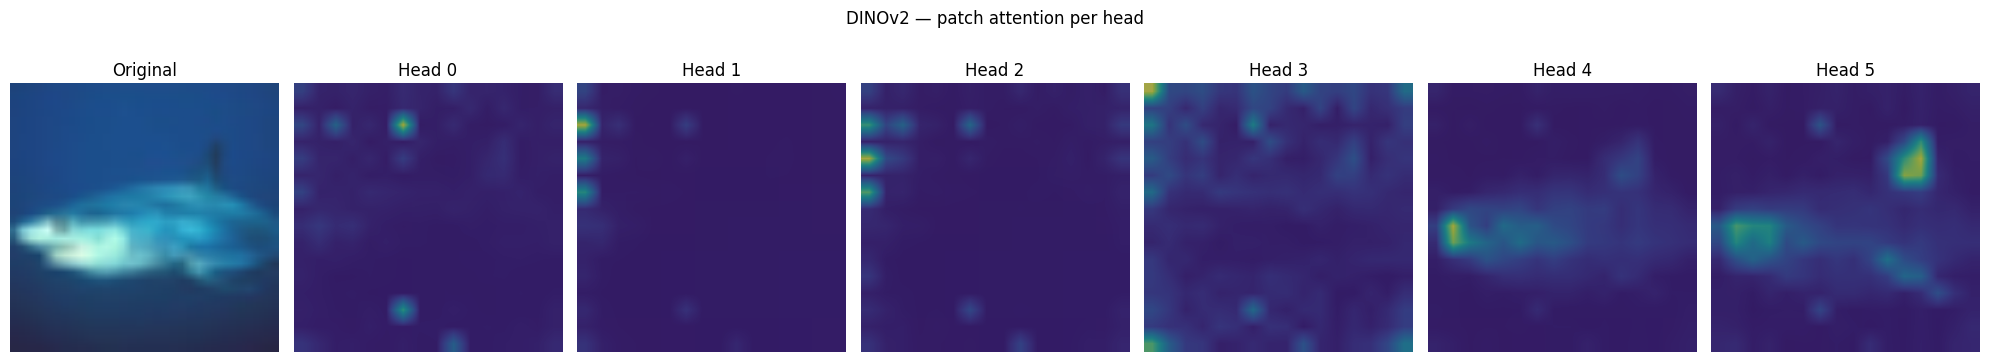

In [105]:
patch_idx = 64  # +1 because position 0 is CLS
patch_attn = attn_weights[0, :, patch_idx + 1, 1:]  # [6, 256]
patch_attn = patch_attn.reshape(6, 16, 16)

fig, axes = plt.subplots(1, 7, figsize=(20, 4))

# Original image
axes[0].imshow(img_display.permute(1, 2, 0))
axes[0].set_title("Original")

# Each head's attention
for i in range(6):
    axes[i+1].imshow(img_display.permute(1, 2, 0))
    axes[i+1].imshow(patch_attn[i].cpu(), alpha=0.6, cmap='viridis', interpolation='bilinear')
    axes[i+1].set_title(f"Head {i}")

for ax in axes:
    ax.axis('off')
plt.suptitle("DINOv2 — patch attention per head")
plt.tight_layout()
plt.show()

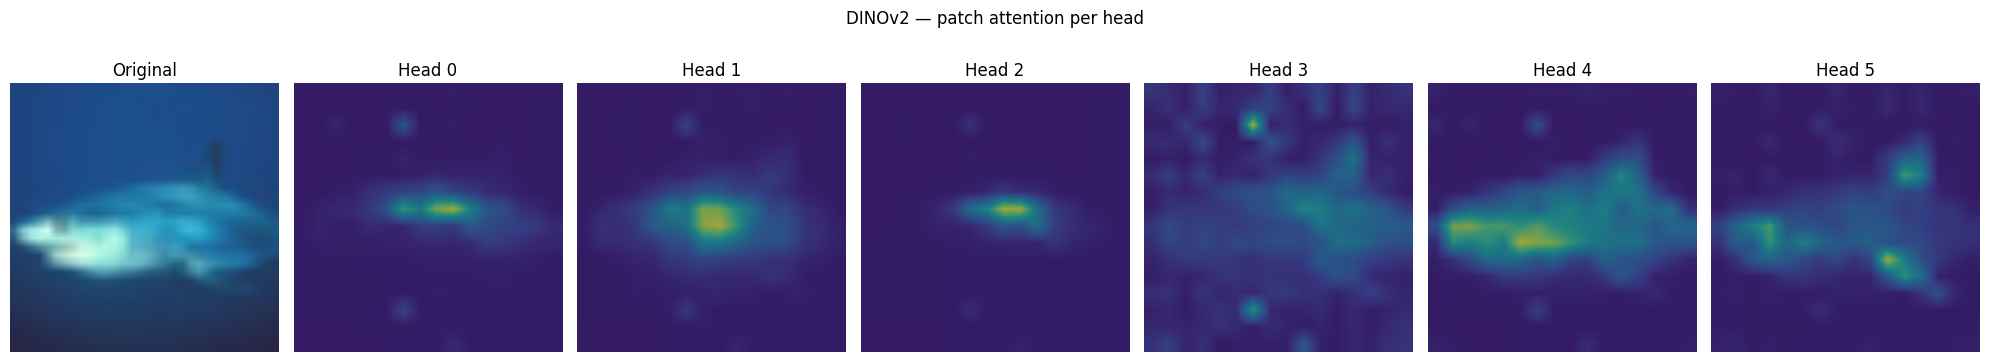

In [106]:
patch_idx = 120  # +1 because position 0 is CLS
patch_attn = attn_weights[0, :, patch_idx + 1, 1:]  # [6, 256]
patch_attn = patch_attn.reshape(6, 16, 16)

fig, axes = plt.subplots(1, 7, figsize=(20, 4))

# Original image
axes[0].imshow(img_display.permute(1, 2, 0))
axes[0].set_title("Original")

# Each head's attention
for i in range(6):
    axes[i+1].imshow(img_display.permute(1, 2, 0))
    axes[i+1].imshow(patch_attn[i].cpu(), alpha=0.6, cmap='viridis', interpolation='bilinear')
    axes[i+1].set_title(f"Head {i}")

for ax in axes:
    ax.axis('off')
plt.suptitle("DINOv2 — patch attention per head")
plt.tight_layout()
plt.show()

## CLIP

* lets try with clip. We download a vit-B/16 which has patches of size 16. 

In [116]:
raw_dataset = CIFAR100(root='./data', train=True, download=True)                                                                                               
img_pil, label = raw_dataset[-1]  

In [127]:
from transformers import CLIPVisionModel, CLIPProcessor                                                                                                        
from torchvision.datasets import CIFAR100
clip_vision = CLIPVisionModel.from_pretrained("openai/clip-vit-base-patch16", attn_implementation="eager")                                                     
clip_vision.eval()
clip_vision = clip_vision.to(device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 41886.21it/s]
CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEX

In [128]:
raw_dataset = CIFAR100(root='./data', train=True, download=True)
img_pil, label = raw_dataset[-1]
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")
inputs = processor(images=img_pil, return_tensors="pt").to(device)

In [129]:
with torch.no_grad():
      outputs = clip_vision(**inputs, output_attentions=True)

In [130]:
last_attn = outputs.attentions[-1]  # [1, 12, 197, 197]
print(last_attn.shape)

torch.Size([1, 12, 197, 197])


In [140]:
clip_cls_attn = last_attn[0, :, 0, 1:].cpu()  # [12, 196]                                                                                                            
clip_cls_attn = clip_cls_attn.reshape(12, 14, 14).cpu()  # 14x14 grid  

In [ ]:
img_tensor = transforms.Compose([                                                                                                                              
      transforms.Resize((224, 224)),
      transforms.ToTensor(),                                                                                                                                     
  ])(img_pil)

img_display = img_tensor.cpu()                                                                                                                                 
cls_attn = cls_attn.cpu()                                                                                                                                      
clip_cls_attn = clip_cls_attn.cpu()

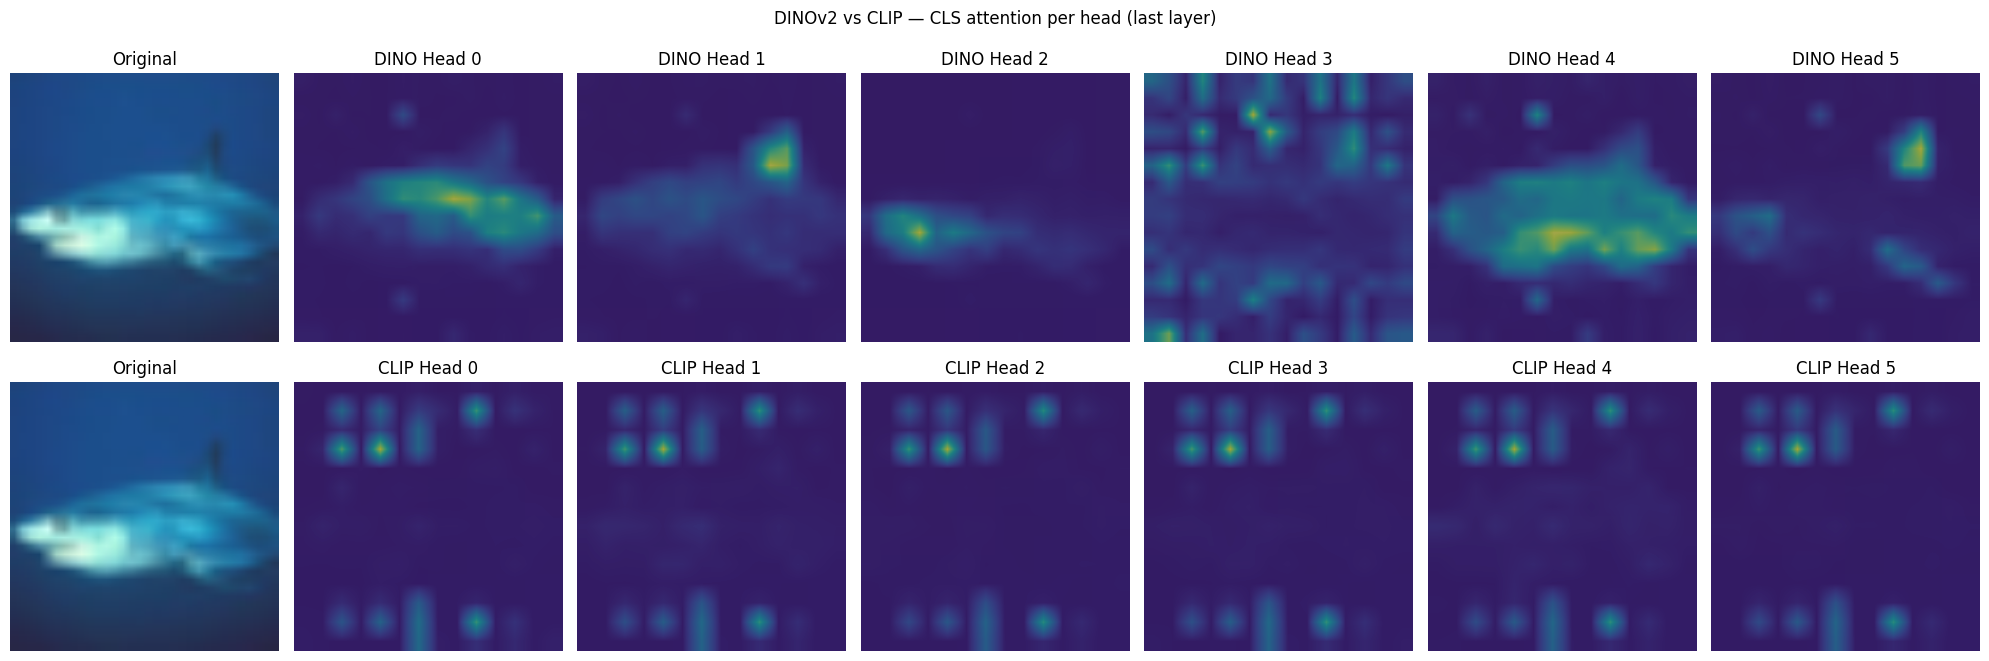

In [143]:
fig, axes = plt.subplots(2, 7, figsize=(20, 7))                                                                                                                
                                                                                                                                                                 
# Top row: DINOv2 (6 heads)
axes[0, 0].imshow(img_display.permute(1, 2, 0))
axes[0, 0].set_title("Original")
for i in range(6):
    axes[0, i+1].imshow(img_display.permute(1, 2, 0))
    axes[0, i+1].imshow(cls_attn[i].cpu(), alpha=0.6, cmap='viridis', interpolation='bilinear')
    axes[0, i+1].set_title(f"DINO Head {i}")

# Bottom row: CLIP (first 6 of 12 heads)
axes[1, 0].imshow(img_display.permute(1, 2, 0))
axes[1, 0].set_title("Original")
for i in range(6):
    axes[1, i+1].imshow(img_display.permute(1, 2, 0))
    axes[1, i+1].imshow(clip_cls_attn[i].cpu(), alpha=0.6, cmap='viridis', interpolation='bilinear')
    axes[1, i+1].set_title(f"CLIP Head {i}")

for ax in axes.flat:
    ax.axis('off')
plt.suptitle("DINOv2 vs CLIP — CLS attention per head (last layer)")
plt.tight_layout()
plt.show()

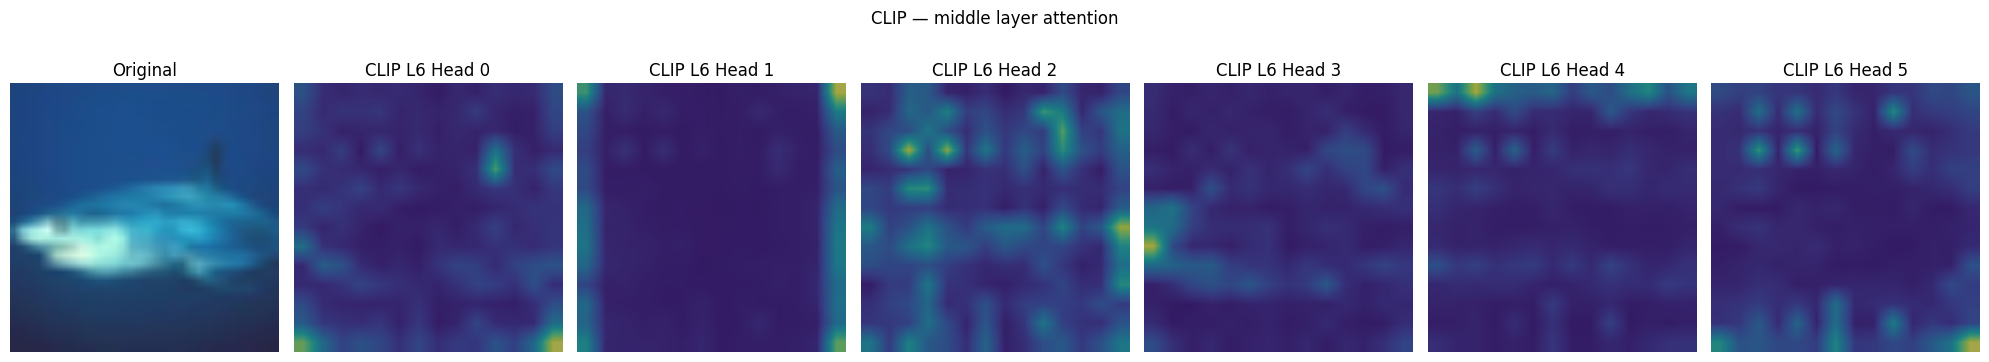

In [145]:
mid_attn = outputs.attentions[5]  # 0-indexed, so index 5 = layer 6
mid_cls_attn = mid_attn[0, :, 0, 1:].reshape(12, 14, 14).cpu()

fig, axes = plt.subplots(1, 7, figsize=(20, 4))
axes[0].imshow(img_display.permute(1, 2, 0))
axes[0].set_title("Original")
for i in range(6):
    axes[i+1].imshow(img_display.permute(1, 2, 0))
    axes[i+1].imshow(mid_cls_attn[i], alpha=0.6, cmap='viridis', interpolation='bilinear')
    axes[i+1].set_title(f"CLIP L6 Head {i}")
for ax in axes:
    ax.axis('off')
plt.suptitle("CLIP — middle layer attention")
plt.tight_layout()
plt.show()

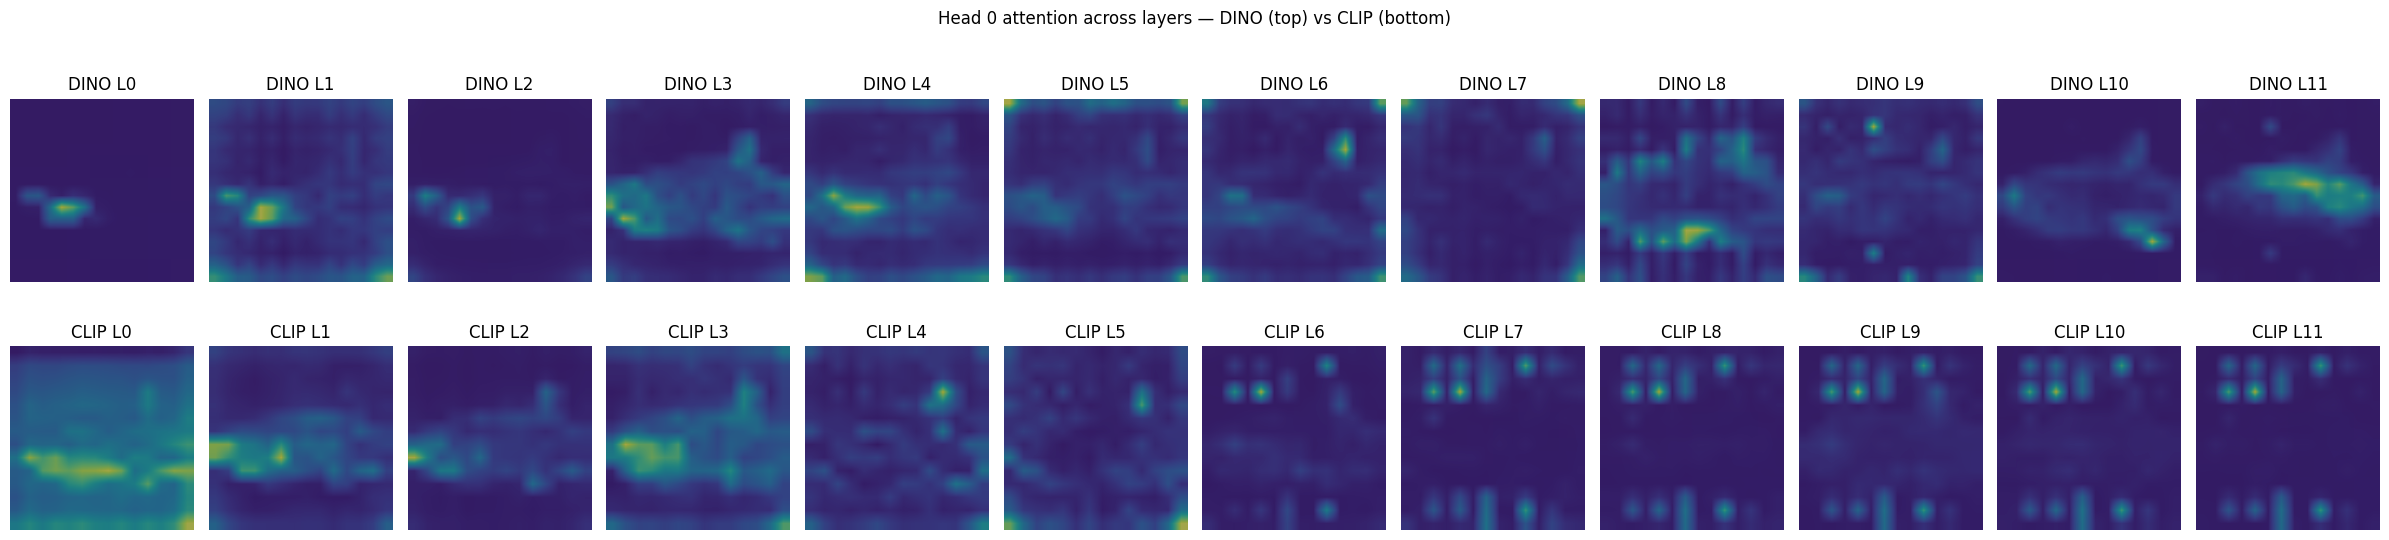

In [148]:
dino_layers = []
with torch.no_grad():
    x = dinov2.prepare_tokens_with_masks(img.unsqueeze(0).to(device))
    for block in dinov2.blocks:
        attn = block.attn
        B, N, C = x.shape
        qkv = attn.qkv(block.norm1(x)).reshape(B, N, 3, attn.num_heads, C // attn.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        weights = (q @ k.transpose(-2, -1)) * attn.scale
        weights = weights.softmax(dim=-1)
        dino_layers.append(weights[0, 0, 0, 1:].cpu().reshape(16, 16))  # head 0, CLS row
        x = block(x)

fig, axes = plt.subplots(2, len(dino_layers), figsize=(24, 6))
for i, attn_map in enumerate(dino_layers):
    axes[0, i].imshow(img_display.permute(1, 2, 0))
    axes[0, i].imshow(attn_map, alpha=0.6, cmap='viridis', interpolation='bilinear')
    axes[0, i].set_title(f"DINO L{i}")

for i, layer_attn in enumerate(outputs.attentions):
    axes[1, i].imshow(img_display.permute(1, 2, 0))
    axes[1, i].imshow(layer_attn[0, 0, 0, 1:].cpu().reshape(14, 14), alpha=0.6, cmap='viridis', interpolation='bilinear')
    axes[1, i].set_title(f"CLIP L{i}")

for ax in axes.flat:
    ax.axis('off')
plt.suptitle("Head 0 attention across layers — DINO (top) vs CLIP (bottom)")
plt.tight_layout()
plt.show()

Notice how the last layers in CLIP dont make that much sense? This is one of the differences in using self-supervised vs language-supervised pre-training. CLIP is forced to compress those representations into a single cls_token so that it can be comapred to its language token. 

Dino can keep things more sharp since the student is tasked with matching the representation of the teacher. So since we feed crops in DINO, we force the model to remebeber everything in the image so it can get good contrastive scores against its teacher. 

The first layers in CLIP are very sharp though since thats where its keeping intermediate representations of the image. The last layers become more of a "summary"

## Using these models to classify CIFAR100